# Customer Segmentation for a UK Online Retailer
## Grouping customers by how they buy, so marketing can stop sending one campaign to everyone

**IIB415A · Business Intelligence · Universidad del Desarrollo**
Prof. Christopher Castro Araya, MSc. · Semester 2026

**Team 4**

| # | Member | Student ID |
|---|--------|-----------|
| 1 | Nicolas Bravo | 20431749-6 |
| 2 | Maria Jose Lopez | 21675751-3 |
| 3 | Matias Mouat | 21610229-0 |
| 4 | Martin Olivares | 21644638-0 |
| 5 | Santiago Page | 21612007-8 |

**Dataset:** Online Retail, from the UCI Machine Learning Repository
**Source:** https://archive.ics.uci.edu/dataset/352/online+retail

---

### How to read this notebook

We follow the five stages of the BI pipeline the assignment asks for:

| Stage | Content | Section |
|-------|---------|---------|
| 1 | Frame and KPIs | §1 |
| 2 | Prepare data | §2 |
| 3 | Model and evaluate | §3 |
| 4 | Communicate | §4 |
| 5 | Ethics and limitations | §5 |

Every number and every chart comes from the cell right above it. A fresh **Restart & Run
All** reproduces all of them with no manual steps. The random seed is set once, in §1.6.

---
# 1 · Frame and KPIs

## 1.1 The client and the problem

We are acting as an external BI team hired by the marketing department of a UK online gift
retailer. The company sells mostly to small businesses across Europe, through its website.

Today marketing sends the same campaign to everybody: same email, same discount, same
reminder frequency. That wastes money in two directions at once. Loyal customers get
discounts they did not need, and customers who are drifting away get nothing that would
bring them back.

## 1.2 Business question

> How can we group customers by the way they actually buy, so that the marketing budget
> goes where it changes behaviour instead of being spread evenly over everyone?

## 1.3 Who decides what

| | |
|---|---|
| **Decision-maker** | Head of CRM / Marketing Manager |
| **Decision** | How to split the quarterly retention budget across the customer base |
| **What changes** | One generic campaign becomes a few differentiated treatments: retention offer, loyalty reward, reactivation, low-cost nurture |
| **Unit of analysis** | One row = one customer (`CustomerID`) |

## 1.4 Why segmentation and not prediction

The dataset has no label telling us who is "valuable" or "about to churn". We would have to
invent that label ourselves, and then the model would just be learning our own rule back at
us. So we use unsupervised segmentation and let the buying behaviour define the groups.

## 1.5 KPIs and what counts as success

Business KPIs the segmentation is meant to move:

| KPI | Definition | Why it matters here |
|-----|-----------|---------------------|
| Revenue concentration | % of revenue coming from the top segment | Shows marketing where the money actually is |
| Retention rate | % of customers who buy again next period | The main thing the campaign is trying to move |
| Marketing cost per customer | Campaign spend / customers contacted | Segmentation should let us spend less on low-potential customers |
| Average order value | Revenue / number of invoices | Warns us if the offers are eating margin |

Inside the notebook we can only measure the technical side of that:

- **Silhouette score on customers the model never saw.** It tells us whether the segments
  are tight and well separated on held-out data.
- **Interpretability.** Each cluster has to be describable in one sentence that a marketing
  manager can act on. A statistically clean cluster nobody can name is useless.

We fix the bar now, before seeing any result: **silhouette above 0.40 on held-out
customers**, and every segment gets its own marketing treatment. §3.6 checks it.

---
## 1.6 Setup and reproducibility

One seed, set here and reused everywhere. No other cell sets a seed.

In [1]:
# Standard library
import warnings
import base64
import io
from datetime import timedelta

# Third party
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

warnings.filterwarnings("ignore")

# One seed for the whole notebook, so every run produces the same numbers
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot defaults, picked to stay readable on a projector
plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

# Colours reused by every chart below
PALETTE = ["#0B6E6E", "#D98C1F", "#3E6B9B", "#A6484A", "#6B8E4E", "#7A5C99"]

print("pandas      ", pd.__version__)
print("numpy       ", np.__version__)
print("matplotlib  ", matplotlib.__version__)
print("scikit-learn", sklearn.__version__)
print("RANDOM_STATE", RANDOM_STATE)

pandas       3.0.5
numpy        2.5.1
matplotlib   3.11.1
scikit-learn 1.9.0
RANDOM_STATE 42


---
# 2 · Prepare data

## 2.1 Loading the file

`Online Retail.xlsx` is included in the submission. It can also be downloaded from UCI
(link in the README).

We read `CustomerID` as text on purpose. It is an identifier, not a quantity. Read as a
number it prints as `17850.0`, and pandas would happily compute its average, which means
nothing.

In [2]:
# Only this line needs changing if the file lives somewhere else
DATA_PATH = "Online Retail.xlsx"

df_raw = pd.read_excel(DATA_PATH, dtype={"CustomerID": str})

print(f"Rows: {df_raw.shape[0]:,}   Columns: {df_raw.shape[1]}")
df_raw.head()

Rows: 541,909   Columns: 8


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [3]:
# Column types and how many non-null values each column has
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  str           
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), object(3), str(2)
memory usage: 42.0+ MB


### Data dictionary

| Column | Type | Meaning |
|--------|------|---------|
| `InvoiceNo` | categorical | Invoice number. A code starting with **C** means a cancellation |
| `StockCode` | categorical | Product code |
| `Description` | text | Product name |
| `Quantity` | numeric | Units in the line. Negative on cancellations and returns |
| `InvoiceDate` | datetime | When the transaction happened |
| `UnitPrice` | numeric | Price per unit, in GBP |
| `CustomerID` | categorical | Customer identifier. Missing on a large share of rows |
| `Country` | categorical | Country of the customer |

The file mixes numeric columns (`Quantity`, `UnitPrice`) with categorical ones
(`StockCode`, `Country`, `InvoiceNo`) and covers about a year of real transactions, which
is what the assignment asks for.

## 2.2 What is wrong with this data

We measure the problems before fixing anything. Every cleaning rule in §2.3 points back to
a number produced here.

In [4]:
# How many values are missing, and in which columns
missing = pd.DataFrame({
    "n_missing": df_raw.isna().sum(),
    "pct_missing": (df_raw.isna().mean() * 100).round(2),
})
missing = missing[missing["n_missing"] > 0]

print("MISSING VALUES")
print(missing.to_string())

MISSING VALUES
             n_missing  pct_missing
Description       1454         0.27
CustomerID      135080        24.93


In [5]:
# Count each known quality problem. The categories overlap on purpose:
# a cancellation line normally also carries a negative quantity.
total_rows = len(df_raw)

problems = {
    "Cancellation invoices (InvoiceNo starts with 'C')": df_raw["InvoiceNo"].astype(str).str.startswith("C").sum(),
    "Quantity <= 0": (df_raw["Quantity"] <= 0).sum(),
    "UnitPrice <= 0": (df_raw["UnitPrice"] <= 0).sum(),
    "Exact duplicate rows": df_raw.duplicated().sum(),
    "Missing CustomerID": df_raw["CustomerID"].isna().sum(),
}

print(f"Total rows: {total_rows:,}\n")
for problem, n_rows in problems.items():
    print(f"  {problem:<52} {n_rows:>7,}  ({n_rows / total_rows * 100:5.2f}%)")

Total rows: 541,909

  Cancellation invoices (InvoiceNo starts with 'C')      9,288  ( 1.71%)
  Quantity <= 0                                         10,624  ( 1.96%)
  UnitPrice <= 0                                         2,517  ( 0.46%)
  Exact duplicate rows                                   5,268  ( 0.97%)
  Missing CustomerID                                   135,080  (24.93%)


In [6]:
# The numeric columns have an extreme range, which matters later for the clustering
print("QUANTITY")
print(df_raw["Quantity"].describe().round(2).to_string())

print("\nUNIT PRICE")
print(df_raw["UnitPrice"].describe().round(2).to_string())

print("\nDATE RANGE")
print(f"  from {df_raw['InvoiceDate'].min()}  to  {df_raw['InvoiceDate'].max()}")

QUANTITY
count    541909.00
mean          9.55
std         218.08
min      -80995.00
25%           1.00
50%           3.00
75%          10.00
max       80995.00

UNIT PRICE
count    541909.00
mean          4.61
std          96.76
min      -11062.06
25%           1.25
50%           2.08
75%           4.13
max       38970.00

DATE RANGE
  from 2010-12-01 08:26:00  to  2011-12-09 12:50:00


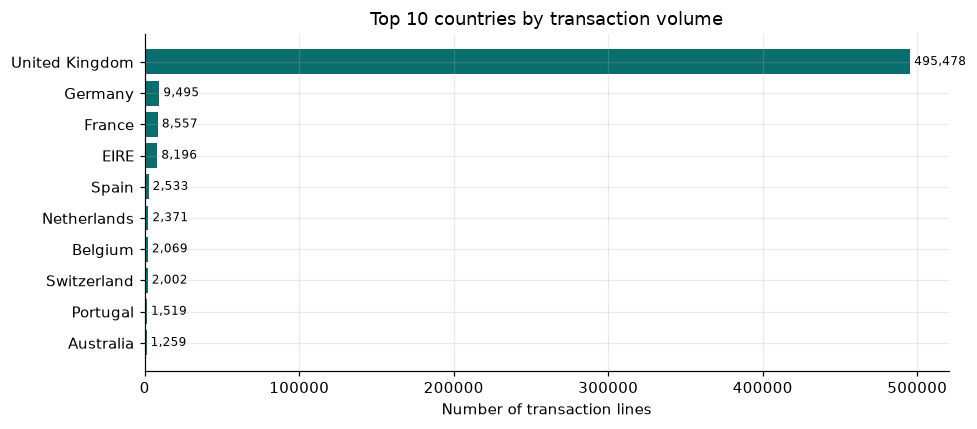

The United Kingdom is 91.4% of all transaction lines.
Distinct countries: 38


In [7]:
# Where do the transactions come from?
top_countries = df_raw["Country"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(top_countries.index[::-1], top_countries.values[::-1], color=PALETTE[0])
ax.set_xlabel("Number of transaction lines")
ax.set_title("Top 10 countries by transaction volume")

# Write the exact count at the end of each bar
for position, value in enumerate(top_countries.values[::-1]):
    ax.text(value, position, f" {value:,}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

uk_share = (df_raw["Country"] == "United Kingdom").mean() * 100
print(f"The United Kingdom is {uk_share:.1f}% of all transaction lines.")
print(f"Distinct countries: {df_raw['Country'].nunique()}")

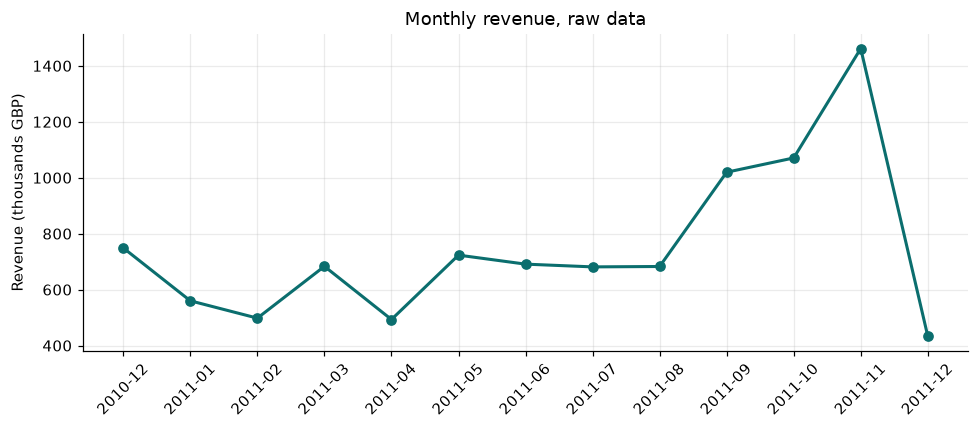

The first and last months are partial, and there is a clear pre-Christmas peak.
We come back to this seasonality as a limitation in §5.


In [8]:
# Monthly revenue, to check whether the year is complete and stable
line_revenue = df_raw["Quantity"] * df_raw["UnitPrice"]
month = df_raw["InvoiceDate"].dt.to_period("M").astype(str)
monthly_revenue = line_revenue.groupby(month).sum() / 1000

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(monthly_revenue.index, monthly_revenue.values, marker="o", color=PALETTE[0], linewidth=2)
ax.set_ylabel("Revenue (thousands GBP)")
ax.set_title("Monthly revenue, raw data")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print("The first and last months are partial, and there is a clear pre-Christmas peak.")
print("We come back to this seasonality as a limitation in §5.")

### What the EDA tells us

1. **`CustomerID` is missing on a big block of rows.** These look like over-the-counter or
   unregistered sales. They cannot be tied to a customer, and the customer is our unit of
   analysis, so we cannot use them.
2. **Cancellations exist and carry negative quantities.** Left in, they would pull down a
   customer's spend and mess up the invoice count.
3. **`UnitPrice` has zeros and negatives.** Those are administrative adjustments, not sales.
4. **There are exact duplicate rows**, probably from the extraction.
5. **The data is dominated by the United Kingdom** and covers roughly one year.

Each of these turns into an explicit cleaning step below.

## 2.3 Cleaning

We apply the steps in a fixed order and print how many rows each one removes, so anyone
reading the notebook can see exactly what was dropped and why. Nothing disappears quietly.

| Step | Rule | Why |
|------|------|-----|
| 1 | Drop exact duplicate rows | Extraction artefacts. They would double-count spend |
| 2 | Drop rows with no `CustomerID` | Cannot be tied to a customer, and the customer is our unit of analysis |
| 3 | Drop cancellation invoices (`InvoiceNo` starts with `C`) | Not purchases. We remove the whole invoice, not just the negative line |
| 4 | Drop `Quantity <= 0` | Returns and corrections, not buying behaviour |
| 5 | Drop `UnitPrice <= 0` | Free items and admin adjustments carry no monetary signal |

**Why we do not impute the missing `CustomerID`.** Imputing it would invent a customer who
does not exist, give them a fake purchase history and put them in a segment. Deleting loses
data but keeps the analysis honest. We state the cost of that in §5.

In [9]:
# Five filters, applied one at a time so we can count what each one removes.
df = df_raw.copy()
rows_at_start = len(df)
removed = {}

# Step 1: exact duplicate rows
before = len(df)
df = df[~df.duplicated()]
removed["1. Exact duplicate rows"] = before - len(df)

# Step 2: rows we cannot attribute to a customer
before = len(df)
df = df[df["CustomerID"].notna()]
removed["2. Missing CustomerID"] = before - len(df)

# Step 3: cancellations
before = len(df)
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
removed["3. Cancellation invoices"] = before - len(df)

# Step 4: returns and corrections
before = len(df)
df = df[df["Quantity"] > 0]
removed["4. Quantity <= 0"] = before - len(df)

# Step 5: free items and administrative adjustments
before = len(df)
df = df[df["UnitPrice"] > 0]
removed["5. UnitPrice <= 0"] = before - len(df)

df = df.copy()

print("CLEANING LOG")
for step, n_removed in removed.items():
    print(f"  {step:<28} -{n_removed:>7,} rows   ({n_removed / rows_at_start * 100:5.2f}% of original)")

print(f"\nOriginal rows     : {rows_at_start:,}")
print(f"Remaining rows    : {len(df):,}  ({len(df) / rows_at_start * 100:.1f}% of original)")
print(f"Distinct customers: {df['CustomerID'].nunique():,}")

CLEANING LOG
  1. Exact duplicate rows      -  5,268 rows   ( 0.97% of original)
  2. Missing CustomerID        -135,037 rows   (24.92% of original)
  3. Cancellation invoices     -  8,872 rows   ( 1.64% of original)
  4. Quantity <= 0             -      0 rows   ( 0.00% of original)
  5. UnitPrice <= 0            -     40 rows   ( 0.01% of original)

Original rows     : 541,909
Remaining rows    : 392,692  (72.5% of original)
Distinct customers: 4,338


In [10]:
# Value of each invoice line, which is what we will add up per customer
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

print(df[["Quantity", "UnitPrice", "Revenue"]].describe().round(2).to_string())
print(f"\nTotal revenue in the cleaned data: GBP {df['Revenue'].sum():,.0f}")

        Quantity  UnitPrice    Revenue
count  392692.00  392692.00  392692.00
mean       13.12       3.13      22.63
std       180.49      22.24     311.10
min         1.00       0.00       0.00
25%         2.00       1.25       4.95
50%         6.00       1.95      12.45
75%        12.00       3.75      19.80
max     80995.00    8142.75  168469.60

Total revenue in the cleaned data: GBP 8,887,209


## 2.4 Feature engineering: the RFM table

The raw data has one row per invoice line. Our unit of analysis is the customer, so we
aggregate up to one row per `CustomerID` and build the three classic RFM features.

| Feature | Definition | Business meaning | Direction |
|---------|-----------|------------------|-----------|
| **Recency** | Days between the customer's last purchase and the snapshot date | Whether they are still active | Lower is better |
| **Frequency** | Number of distinct invoices | How habitual the relationship is | Higher is better |
| **Monetary** | Total revenue generated | What the relationship is worth | Higher is better |

**About the snapshot date.** Recency needs a fixed reference point. We use the day after
the last transaction in the file. Using `pd.Timestamp.now()` would be wrong: the data ends
in 2011, so everyone would look inactive by thousands of days and Recency would carry no
information. Hard-coding a date would break if the dataset were ever updated. Deriving it
from the data avoids both problems.

**Why Frequency counts invoices and not lines.** A customer who buys 40 different products
in one order made one purchase decision, not 40. Counting lines would confuse basket size
with loyalty.

In [11]:
# Reference point for Recency: the day after the last transaction in the file
snapshot_date = df["InvoiceDate"].max() + timedelta(days=1)
print(f"Last transaction : {df['InvoiceDate'].max()}")
print(f"Snapshot date    : {snapshot_date}")

# One aggregation per feature, kept separate so each line is easy to read
last_purchase = df.groupby("CustomerID")["InvoiceDate"].max()
n_invoices = df.groupby("CustomerID")["InvoiceNo"].nunique()
total_spend = df.groupby("CustomerID")["Revenue"].sum()

rfm = pd.DataFrame({
    "Recency": (snapshot_date - last_purchase).dt.days,
    "Frequency": n_invoices,
    "Monetary": total_spend,
})

# The country each customer orders from most often, kept for profiling later
rfm["Country"] = df.groupby("CustomerID")["Country"].agg(lambda countries: countries.mode()[0])

print(f"\nCustomers in the RFM table: {len(rfm):,}")
rfm.head(10)

Last transaction : 2011-12-09 12:50:00
Snapshot date    : 2011-12-10 12:50:00



Customers in the RFM table: 4,338


,Recency,Frequency,Monetary,Country
CustomerID,,,,
12346,326,1,77183.60,United Kingdom
12347,2,7,4310.00,Iceland
12348,75,4,1797.24,Finland
12349,19,1,1757.55,Italy
12350,310,1,334.40,Norway
12352,36,8,2506.04,Norway
12353,204,1,89.00,Bahrain
12354,232,1,1079.40,Spain
12355,214,1,459.40,Bahrain


In [12]:
print("RFM SUMMARY")
print(rfm[["Recency", "Frequency", "Monetary"]].describe().round(2).to_string())

# Skewness near 0 means symmetric. Large positive values mean a long right tail.
print("\nSKEWNESS")
print(rfm[["Recency", "Frequency", "Monetary"]].skew().round(2).to_string())

RFM SUMMARY
       Recency  Frequency   Monetary
count  4338.00    4338.00    4338.00
mean     92.54       4.27    2048.69
std     100.01       7.70    8985.23
min       1.00       1.00       3.75
25%      18.00       1.00     306.48
50%      51.00       2.00     668.57
75%     142.00       5.00    1660.60
max     374.00     209.00  280206.02

SKEWNESS
Recency       1.25
Frequency    12.07
Monetary     19.34


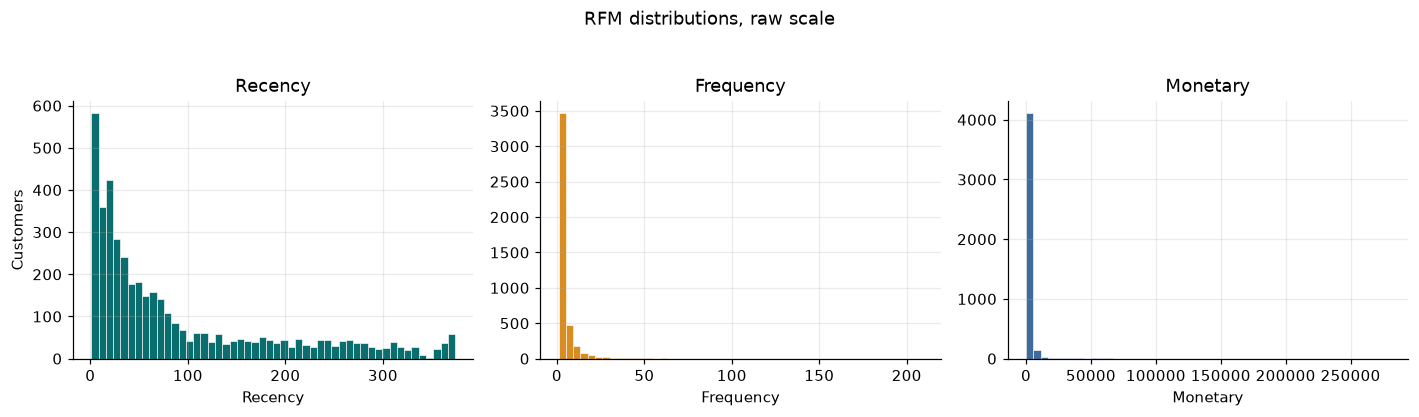

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

for ax, column, colour in zip(axes, ["Recency", "Frequency", "Monetary"], PALETTE):
    ax.hist(rfm[column], bins=50, color=colour, edgecolor="white", linewidth=0.4)
    ax.set_title(column)
    ax.set_xlabel(column)

axes[0].set_ylabel("Customers")
fig.suptitle("RFM distributions, raw scale", y=1.04, fontsize=12)
plt.tight_layout()
plt.show()

### The distributions are heavily right-skewed

`Frequency` and `Monetary` have a very long right tail. Most customers bought a handful of
times for a modest amount, and a small group bought constantly for very large amounts.

That matters because K-means minimises squared Euclidean distance. On a raw skewed scale a
few extreme customers dominate the objective, and the algorithm spends its clusters
isolating them instead of describing the bulk of the customer base.

## 2.5 Outliers: look first, then decide

Before deciding anything, we look at who the extremes actually are.

In [14]:
print("TOP 10 CUSTOMERS BY SPEND")
print(rfm.nlargest(10, "Monetary")[["Recency", "Frequency", "Monetary", "Country"]].round(0).to_string())

# How concentrated is the revenue?
top_1_percent = rfm[rfm["Monetary"] >= rfm["Monetary"].quantile(0.99)]
share = top_1_percent["Monetary"].sum() / rfm["Monetary"].sum() * 100

print(f"\nThe top 1% of customers ({len(top_1_percent)} of them) generate {share:.1f}% of total revenue.")

TOP 10 CUSTOMERS BY SPEND
            Recency  Frequency  Monetary         Country
CustomerID                                              
14646             2         73  280206.0     Netherlands
18102             1         60  259657.0  United Kingdom
17450             8         46  194391.0  United Kingdom
16446             1          2  168472.0  United Kingdom
14911             1        201  143711.0            EIRE
12415            24         21  124915.0       Australia
14156            10         55  117210.0            EIRE
17511             3         31   91062.0  United Kingdom
16029            39         63   80851.0  United Kingdom
12346           326          1   77184.0  United Kingdom

The top 1% of customers (44 of them) generate 32.1% of total revenue.


**Decision: keep the outliers and change the scale instead of deleting rows.**

Those extreme customers are not data errors. They are wholesale buyers, and they are the
most commercially important group in the file. Deleting them would remove exactly the
customers marketing most needs to find.

So we apply a `log1p` transformation to the three features instead. `log1p(x) = log(1 + x)`
compresses the long tail while keeping the order intact, and it is safe at zero, which
matters because Recency is 0 for anyone who bought on the last day. After the transform,
the distance between a typical customer and a very large one is comparable to other
distances, so K-means describes the whole base instead of chasing a few whales.

We only remove records that are logically impossible, and the cell below shows there are
none.

In [15]:
# Sanity check. After the cleaning in §2.3 there should be nothing impossible left.
impossible = (rfm["Monetary"] <= 0) | (rfm["Frequency"] <= 0) | (rfm["Recency"] < 0)
print(f"Logically impossible RFM records: {impossible.sum()}")
rfm = rfm[~impossible].copy()

FEATURES = ["Recency", "Frequency", "Monetary"]
rfm_log = np.log1p(rfm[FEATURES])

print("\nSKEWNESS BEFORE AND AFTER log1p")
print(pd.DataFrame({
    "before": rfm[FEATURES].skew().round(2),
    "after": rfm_log.skew().round(2),
}).to_string())

Logically impossible RFM records: 0

SKEWNESS BEFORE AND AFTER log1p
           before  after
Recency      1.25  -0.38
Frequency   12.07   1.21
Monetary    19.34   0.40


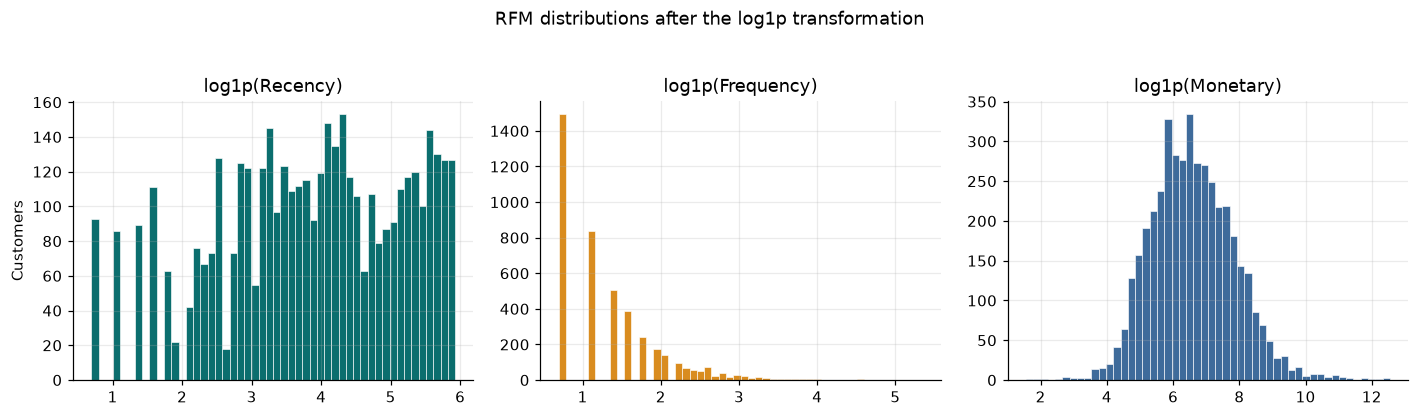

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

for ax, column, colour in zip(axes, FEATURES, PALETTE):
    ax.hist(rfm_log[column], bins=50, color=colour, edgecolor="white", linewidth=0.4)
    ax.set_title(f"log1p({column})")

axes[0].set_ylabel("Customers")
fig.suptitle("RFM distributions after the log1p transformation", y=1.04, fontsize=12)
plt.tight_layout()
plt.show()

## 2.6 Train / test split, and why we bother

K-means is unsupervised, so there is no target to leak. But "no target" is not the same as
"no validation". A clustering can still be overfitted to the specific customers it was
fitted on: the centroids land exactly where those points happen to be, and the structure
falls apart on customers the model never saw.

So we use the same discipline as in supervised learning:

**split → fit → predict → evaluate**

1. **Split** the customers 80% train / 20% test.
2. **Fit** the scaler and the K-means model on the training customers only.
3. **Predict** cluster labels for the test customers with the already-fitted objects.
4. **Evaluate** the silhouette on the test set.

This is where leakage would happen if we were careless. If we called `fit_transform()` on
the full RFM table before splitting, the mean and standard deviation used to scale the
training data would already contain information about the test customers, and the test
score would come out optimistic without us knowing by how much. So we call `fit_transform`
on train and `transform` (never `fit`) on test.

One more thing about why we standardise at all. After `log1p`, Recency runs roughly 0 to 6,
Frequency 0 to 5 and Monetary 3 to 13. Euclidean distance would let Monetary dominate just
because its numbers are bigger. `StandardScaler` puts all three on mean 0 and standard
deviation 1, so each one carries the same weight.

In [17]:
# Step 1: split the customers, before any scaling
X_train_raw, X_test_raw = train_test_split(rfm_log, test_size=0.20, random_state=RANDOM_STATE)

print(f"Training customers: {len(X_train_raw):,}")
print(f"Test customers    : {len(X_test_raw):,}")

# Step 2: fit the scaler on train only, then apply it to both sets
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)   # learns the mean and std, then applies them
X_test = scaler.transform(X_test_raw)         # applies them, never learns from test

print("\nScaler parameters, learned from the training set only:")
print(pd.DataFrame({"mean": scaler.mean_, "std": scaler.scale_}, index=FEATURES).round(3).to_string())
print(f"\nTrain matrix: {X_train.shape}   Test matrix: {X_test.shape}")

Training customers: 3,470
Test customers    : 868

Scaler parameters, learned from the training set only:
            mean    std
Recency    3.826  1.333
Frequency  1.340  0.676
Monetary   6.579  1.256

Train matrix: (3470, 3)   Test matrix: (868, 3)


---
# 3 · Model and evaluate

## 3.1 Choosing the algorithm

K-means fits this problem:

- The three RFM features are continuous and, after `log1p`, roughly unimodal.
- We need compact groups with a representative centre. A centroid reads directly as a
  business sentence: "this segment's average customer last bought 30 days ago, has ordered
  8 times and spent GBP 3,000."
- The customer base is a few thousand rows, so we can afford to re-run it across many
  values of k.

What we considered and rejected:

| Alternative | Why not here |
|---|---|
| Hierarchical clustering | O(n²) memory, and no centroid to hand to marketing |
| DBSCAN | Built to find arbitrary shapes and label noise. RFM space has no natural density gaps, and a large "noise" group is useless for a campaign |
| Manual RFM quintile scoring | We use it as the baseline in §3.5, not as the model |

We run K-means with `n_init=10`, which restarts the algorithm from 10 different random
initialisations and keeps the best. That is what makes the result stable instead of
dependent on one lucky start. `random_state=42` makes those 10 starts identical on every
run, which is what gives us reproducibility.

## 3.2 Choosing k with the elbow and the silhouette

`k` is a decision we have to justify, not a number to guess. We use two statistical
criteria and then cross them with a business one.

- **Inertia (elbow method):** within-cluster sum of squares. It always falls as k grows, so
  we look for the bend where extra clusters stop buying much improvement.
- **Silhouette score:** for each point, how much closer it is to its own cluster than to the
  nearest other one. It runs from -1 to 1, and higher is better.

Both are computed on the training set only. We do not touch the test set until §3.4.

In [18]:
# Fit one model per candidate k and record how good each one is
rows = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = model.fit_predict(X_train)
    rows.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(X_train, labels),
        "davies_bouldin": davies_bouldin_score(X_train, labels),
        "calinski_harabasz": calinski_harabasz_score(X_train, labels),
    })

k_search = pd.DataFrame(rows).set_index("k")

print("MODEL SELECTION (training set)")
print("  silhouette        : higher is better")
print("  davies_bouldin    : LOWER is better")
print("  calinski_harabasz : higher is better\n")
print(k_search.round(3).to_string())

MODEL SELECTION (training set)
  silhouette        : higher is better
  davies_bouldin    : LOWER is better
  calinski_harabasz : higher is better

     inertia  silhouette  davies_bouldin  calinski_harabasz
k                                                          
2   5182.819       0.433           0.891           3497.687
3   3903.764       0.334           1.058           2889.182
4   3158.211       0.336           1.014           2652.964
5   2659.719       0.314           0.999           2524.235
6   2304.362       0.308           1.023           2436.972
7   2056.979       0.306           0.989           2343.784
8   1883.877       0.299           1.004           2238.364
9   1744.671       0.279           1.016           2148.767
10  1622.678       0.275           1.033           2081.898


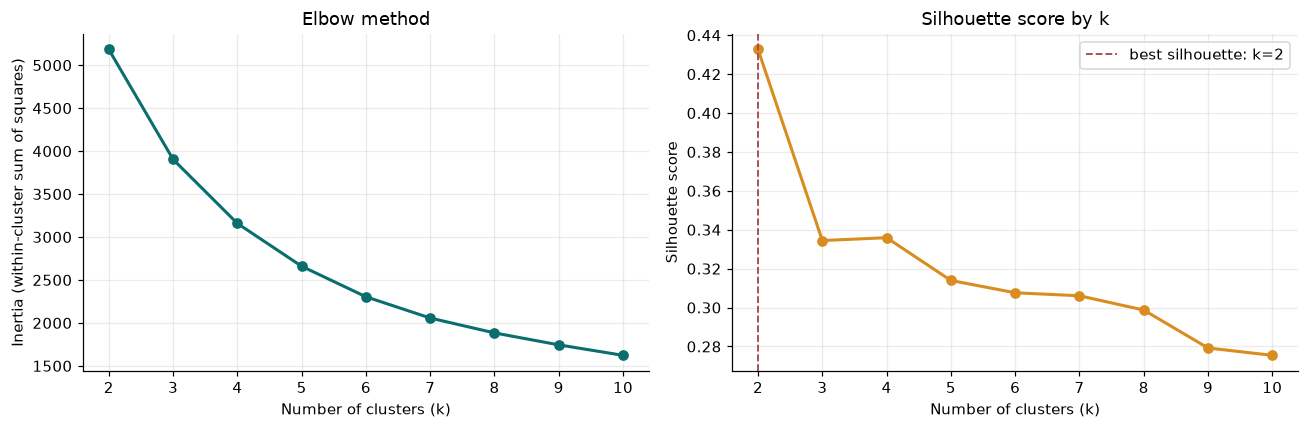

Highest silhouette on train: k=2 (0.433)


In [19]:
best_k_by_metric = int(k_search["silhouette"].idxmax())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_search.index, k_search["inertia"], marker="o", color=PALETTE[0], linewidth=2)
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia (within-cluster sum of squares)")
axes[0].set_title("Elbow method")

axes[1].plot(k_search.index, k_search["silhouette"], marker="o", color=PALETTE[1], linewidth=2)
axes[1].axvline(best_k_by_metric, color=PALETTE[3], linestyle="--", linewidth=1.2,
                label=f"best silhouette: k={best_k_by_metric}")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette score by k")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Highest silhouette on train: k={best_k_by_metric} ({k_search['silhouette'].max():.3f})")

### The decision on k

The metrics above give a purely statistical ranking. The business adds a second constraint:

> Every segment has to map to a marketing action the department can actually fund and run.

With k = 2 the segmentation only says "good customers and bad customers", which marketing
already knows. With k = 9 or 10 the team would have to design nine campaigns, and several
segments would be too small to justify one.

So we go with **k = 4**, as long as its silhouette is close to the statistical optimum. Four
is what the CRM team can operate: one retention treatment, one loyalty treatment, one
reactivation treatment and one low-cost nurture treatment.

The cell below states the choice and prints what it costs us in silhouette points against
the statistical best. It is also the single place to change k.

In [20]:
K = 4   # the chosen number of segments

silhouette_at_K = k_search.loc[K, "silhouette"]
silhouette_at_best = k_search.loc[best_k_by_metric, "silhouette"]

print(f"Chosen k                     : {K}")
print(f"Silhouette at k={K} (train)    : {silhouette_at_K:.3f}")
print(f"Best statistical k           : {best_k_by_metric}")
print(f"Silhouette at that k (train) : {silhouette_at_best:.3f}")
print(f"Cost of the business choice  : {silhouette_at_best - silhouette_at_K:.3f} silhouette points")

Chosen k                     : 4
Silhouette at k=4 (train)    : 0.336
Best statistical k           : 2
Silhouette at that k (train) : 0.433
Cost of the business choice  : 0.097 silhouette points


## 3.3 Fit on train

The model sees the training customers only.

In [21]:
# Step 3: fit on train
kmeans = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE)
kmeans.fit(X_train)
train_labels = kmeans.labels_

print(f"Fitted on {len(X_train):,} training customers.")
print(f"Converged in {kmeans.n_iter_} iterations.")
print("\nCluster sizes in the training set:")
print(pd.Series(train_labels).value_counts().sort_index().to_string())

Fitted on 3,470 training customers.
Converged in 19 iterations.

Cluster sizes in the training set:
0     667
1    1296
2     936
3     571


## 3.4 Predict on the held-out customers and evaluate honestly

Now the model assigns clusters to customers it has never seen. If the segmentation reflects
real structure and not an artefact of the training sample, the test silhouette should land
close to the training one. A big drop would mean we fitted noise.

In [22]:
# Step 4: predict on the held-out customers
test_labels = kmeans.predict(X_test)

# Step 5: evaluate. The two silhouettes are kept in variables because we quote them later.
sil_train = silhouette_score(X_train, train_labels)
sil_test = silhouette_score(X_test, test_labels)

evaluation = pd.DataFrame(
    {
        "Train": [sil_train,
                  davies_bouldin_score(X_train, train_labels),
                  calinski_harabasz_score(X_train, train_labels)],
        "Test (held-out)": [sil_test,
                            davies_bouldin_score(X_test, test_labels),
                            calinski_harabasz_score(X_test, test_labels)],
    },
    index=["Silhouette (higher is better)",
           "Davies-Bouldin (lower is better)",
           "Calinski-Harabasz (higher is better)"],
)

print("EVALUATION")
print(evaluation.round(3).to_string())
print(f"\nSilhouette change from train to test: {sil_test - sil_train:+.4f}")
print("A small change means the segment structure holds on unseen customers.")

EVALUATION
                                         Train  Test (held-out)
Silhouette (higher is better)            0.336            0.337
Davies-Bouldin (lower is better)         1.014            0.995
Calinski-Harabasz (higher is better)  2652.964          682.124

Silhouette change from train to test: +0.0008
A small change means the segment structure holds on unseen customers.


In [23]:
# Do the segments come out in similar proportions on both sets?
proportions = pd.DataFrame({
    "train_%": pd.Series(train_labels).value_counts(normalize=True).sort_index() * 100,
    "test_%": pd.Series(test_labels).value_counts(normalize=True).sort_index() * 100,
}).round(2)
proportions["difference"] = (proportions["test_%"] - proportions["train_%"]).round(2)

print("CLUSTER PROPORTIONS: TRAIN vs TEST")
print(proportions.to_string())

CLUSTER PROPORTIONS: TRAIN vs TEST
   train_%  test_%  difference
0    19.22   19.24        0.02
1    37.35   36.98       -0.37
2    26.97   26.61       -0.36
3    16.46   17.17        0.71


## 3.5 Baselines: is K-means adding anything?

A metric with nothing to compare against means very little, so we set up two baselines.

**Baseline 1, random assignment.** Split the customers into K groups at random. This is the
floor: a silhouette near 0 is what "no structure at all" looks like. If K-means did not beat
this, our segments would be noise.

**Baseline 2, traditional RFM quintile scoring.** This is what a marketing department does
without a data science team: score each customer 1 to 5 on R, F and M, add the scores up and
cut the total into groups. It is a legitimate method and it is the real alternative to our
proposal. If K-means cannot beat it, the honest recommendation is to use the simpler method.

In [24]:
# Baseline 1: random labels
rng = np.random.RandomState(RANDOM_STATE)
random_labels = rng.randint(0, K, size=len(X_test))
sil_random = silhouette_score(X_test, random_labels)

# Baseline 2: classic RFM quintile scoring, on the same held-out customers.
# We rank first and cut the ranks into five equal groups. Ranking with method="first"
# breaks ties, which keeps the five groups the same size.
test_rfm = rfm.loc[X_test_raw.index, FEATURES]

recency_rank = test_rfm["Recency"].rank(method="first", ascending=False)  # fewer days is better
frequency_rank = test_rfm["Frequency"].rank(method="first")
monetary_rank = test_rfm["Monetary"].rank(method="first")

r_score = pd.qcut(recency_rank, 5, labels=[1, 2, 3, 4, 5]).astype(int)
f_score = pd.qcut(frequency_rank, 5, labels=[1, 2, 3, 4, 5]).astype(int)
m_score = pd.qcut(monetary_rank, 5, labels=[1, 2, 3, 4, 5]).astype(int)

# Total score runs from 3 to 15. Cut it into K groups to compare like with like.
total_score = r_score + f_score + m_score
baseline_labels = pd.qcut(total_score.rank(method="first"), K, labels=range(K)).astype(int)
sil_baseline = silhouette_score(X_test, baseline_labels)

print("BASELINE COMPARISON, all on the same held-out customers")
print(f"  Random assignment (floor)        {sil_random:.3f}")
print(f"  Traditional RFM quintile scoring {sil_baseline:.3f}")
print(f"  K-means (k={K})                    {sil_test:.3f}")
print(f"\nK-means beats the quintile baseline by {sil_test - sil_baseline:+.3f} silhouette points.")

BASELINE COMPARISON, all on the same held-out customers
  Random assignment (floor)        -0.020
  Traditional RFM quintile scoring 0.170
  K-means (k=4)                    0.337

K-means beats the quintile baseline by +0.167 silhouette points.


## 3.6 Result against the bar we set in §1.5

We committed in advance to a silhouette above 0.40 on held-out customers. The cell below
checks that, without moving the bar after the fact.

In [25]:
TARGET_SILHOUETTE = 0.40
target_met = sil_test > TARGET_SILHOUETTE

print(f"Target set in §1.5       : silhouette > {TARGET_SILHOUETTE}")
print(f"Achieved on held-out set : {sil_test:.3f}")
print(f"Result                   : {'MET' if target_met else 'NOT MET'}\n")

if target_met:
    print("The segments are internally coherent and separate well on unseen customers.")
else:
    print("We did not reach the bar. The segments are still usable, because they are")
    print("interpretable and they beat both baselines, but the boundaries between")
    print("neighbouring segments are soft. We report this as a limitation in §5.")

Target set in §1.5       : silhouette > 0.4
Achieved on held-out set : 0.337
Result                   : NOT MET

We did not reach the bar. The segments are still usable, because they are
interpretable and they beat both baselines, but the boundaries between
neighbouring segments are soft. We report this as a limitation in §5.


## 3.7 Final model for delivery

The evaluation above is finished: we fitted on train and judged on unseen customers. For
the deliverable itself we now refit the scaler and the model on all customers, so that
everyone in the client's database gets a segment.

This is a deliberate and standard choice. The held-out run already told us the method works,
and the production model should use all the data available. It is not leakage, because we do
not report any evaluation from this model. Every number in §3.4 to §3.6 comes from the
held-out run.

In [26]:
scaler_full = StandardScaler()
X_full = scaler_full.fit_transform(rfm_log)

kmeans_full = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE)
rfm["Cluster"] = kmeans_full.fit_predict(X_full)

print(f"Final model fitted on all {len(rfm):,} customers.")
print(f"Silhouette on the full dataset: {silhouette_score(X_full, rfm['Cluster']):.3f}")
print(f"\nThat number is here for completeness. The honest estimate of how the model")
print(f"generalises is still the held-out {sil_test:.3f} from §3.4.")
print("\nCluster sizes:")
print(rfm["Cluster"].value_counts().sort_index().to_string())

Final model fitted on all 4,338 customers.


Silhouette on the full dataset: 0.338

That number is here for completeness. The honest estimate of how the model
generalises is still the held-out 0.337 from §3.4.

Cluster sizes:
Cluster
0     713
1    1622
2     837
3    1166


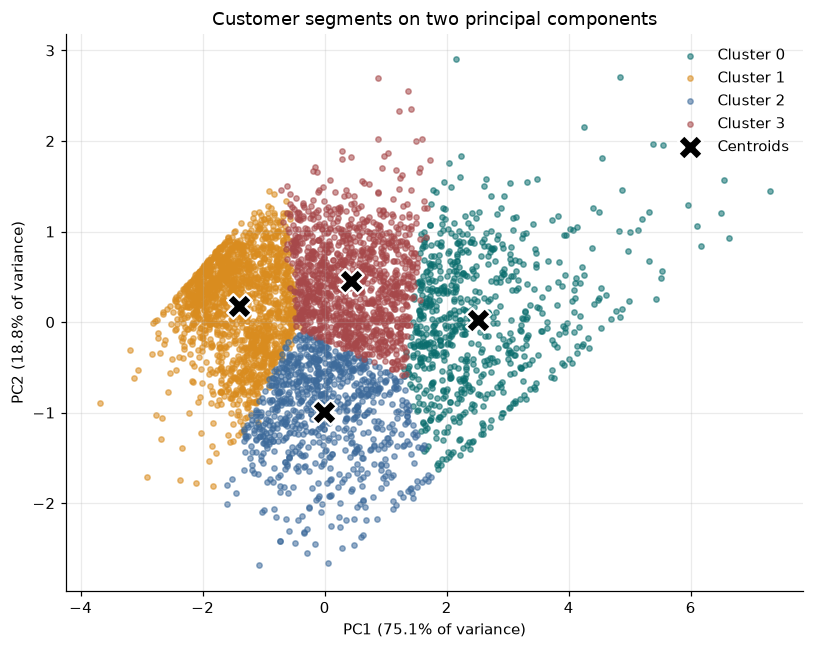

The two components keep 93.9% of the variance, so this picture is a
fair summary of the 3-dimensional structure.
PCA is used for the picture only. The clustering ran on the three scaled RFM
features, not on these components.


In [27]:
# Visual check: squeeze the three scaled features into two dimensions and look at them
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_full)
centroids_2d = pca.transform(kmeans_full.cluster_centers_)

fig, ax = plt.subplots(figsize=(7.5, 6))

for cluster in sorted(rfm["Cluster"].unique()):
    in_cluster = rfm["Cluster"].values == cluster
    ax.scatter(coords[in_cluster, 0], coords[in_cluster, 1], s=12, alpha=0.55,
               color=PALETTE[cluster], label=f"Cluster {cluster}")

ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1], marker="X", s=260,
           c="black", edgecolor="white", linewidth=1.5, label="Centroids", zorder=5)

variance = pca.explained_variance_ratio_
ax.set_xlabel(f"PC1 ({variance[0] * 100:.1f}% of variance)")
ax.set_ylabel(f"PC2 ({variance[1] * 100:.1f}% of variance)")
ax.set_title("Customer segments on two principal components")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(f"The two components keep {variance.sum() * 100:.1f}% of the variance, so this picture is a")
print("fair summary of the 3-dimensional structure.")
print("PCA is used for the picture only. The clustering ran on the three scaled RFM")
print("features, not on these components.")

---
# 4 · Communicate

## 4.1 Segment profiles

A cluster number is not a business object. We describe each cluster in the original units,
days, orders and GBP, because that is the only version a marketing manager can act on.

In [28]:
profile = rfm.groupby("Cluster").agg(
    Customers=("Recency", "size"),
    Avg_Recency_days=("Recency", "mean"),
    Avg_Frequency_orders=("Frequency", "mean"),
    Avg_Monetary_GBP=("Monetary", "mean"),
    Median_Monetary_GBP=("Monetary", "median"),
    Total_Revenue_GBP=("Monetary", "sum"),
).round(1)

profile["Pct_of_Customers"] = (profile["Customers"] / profile["Customers"].sum() * 100).round(1)
profile["Pct_of_Revenue"] = (profile["Total_Revenue_GBP"] / profile["Total_Revenue_GBP"].sum() * 100).round(1)

print("SEGMENT PROFILES (original units)")
print(profile.to_string())

SEGMENT PROFILES (original units)
         Customers  Avg_Recency_days  Avg_Frequency_orders  Avg_Monetary_GBP  Median_Monetary_GBP  Total_Revenue_GBP  Pct_of_Customers  Pct_of_Revenue
Cluster                                                                                                                                               
0              713              12.2                  13.8            8088.0               3722.8          5766757.1              16.4            64.9
1             1622             181.5                   1.3             341.0                296.1           553099.8              37.4             6.2
2              837              17.7                   2.2             557.3                480.3           466479.0              19.3             5.2
3             1166              71.6                   4.1            1801.8               1345.2          2100873.0              26.9            23.6


## 4.2 Naming the segments

K-means numbers its clusters 0, 1, 2, 3. Those numbers are arbitrary, they can change if the
seed changes, and they mean nothing to a marketing manager. So we derive the names from the
profile table using a rule we write down first:

1. **Champions** are the best combination of high Frequency, high Monetary and low Recency.
2. **Loyal Customers** are, of the rest, the ones still buying (lowest average Recency).
3. **At Risk** are, of the two inactive clusters, the ones who used to spend more.
4. **Low Engagement** are the remaining inactive, low-value cluster.

Steps 3 and 4 are the ones that matter. A single combined ranking cannot separate "used to
be valuable and stopped" from "never really bought", because both can score the same overall
for completely different reasons, and they need opposite treatments.

In [29]:
# This rule is written for four segments. If you change K above, rewrite the block below.
assert K == 4, "The naming rule below assumes four segments."

# Rank the clusters on each dimension. Higher rank means better.
rank_frequency = profile["Avg_Frequency_orders"].rank()
rank_monetary = profile["Avg_Monetary_GBP"].rank()
rank_recency = profile["Avg_Recency_days"].rank(ascending=False)   # fewer days is better
value_score = rank_frequency + rank_monetary + rank_recency

# 1. Champions: best overall.
champions = value_score.idxmax()

# 2. Loyal Customers: of the rest, the cluster still buying.
others = profile.drop(index=champions)
loyal = others["Avg_Recency_days"].idxmin()

# 3 and 4. The two inactive clusters. The one that used to spend more is At Risk.
inactive = others.drop(index=loyal)
at_risk = inactive["Avg_Monetary_GBP"].idxmax()
low_engagement = inactive["Avg_Monetary_GBP"].idxmin()

segment_name = {
    champions: "Champions",
    loyal: "Loyal Customers",
    at_risk: "At Risk",
    low_engagement: "Low Engagement",
}
segment_description = {
    champions: "Recent, frequent and high-spending. The core of the business.",
    loyal: "Still buying regularly, with solid but smaller baskets.",
    at_risk: "Used to spend real money but have not come back in a long time.",
    low_engagement: "Few orders, low spend, inactive for a long time. Mostly one-time buyers.",
}

# The order we use in every table and chart from here on
order = ["Champions", "Loyal Customers", "At Risk", "Low Engagement"]

rfm["Segment"] = rfm["Cluster"].map(segment_name)
profile["Segment"] = profile.index.map(segment_name)
profile["Description"] = profile.index.map(segment_description)

summary = profile.set_index("Segment").loc[order][[
    "Customers", "Pct_of_Customers", "Avg_Recency_days",
    "Avg_Frequency_orders", "Avg_Monetary_GBP", "Pct_of_Revenue",
]]

print("SEGMENT SUMMARY")
print(summary.to_string())
print("\nCluster number -> business name")
for cluster in sorted(segment_name):
    print(f"  Cluster {cluster} -> {segment_name[cluster]}")

SEGMENT SUMMARY
                 Customers  Pct_of_Customers  Avg_Recency_days  Avg_Frequency_orders  Avg_Monetary_GBP  Pct_of_Revenue
Segment                                                                                                               
Champions              713              16.4              12.2                  13.8            8088.0            64.9
Loyal Customers        837              19.3              17.7                   2.2             557.3             5.2
At Risk               1166              26.9              71.6                   4.1            1801.8            23.6
Low Engagement        1622              37.4             181.5                   1.3             341.0             6.2

Cluster number -> business name
  Cluster 0 -> Champions
  Cluster 1 -> Low Engagement
  Cluster 2 -> Loyal Customers
  Cluster 3 -> At Risk


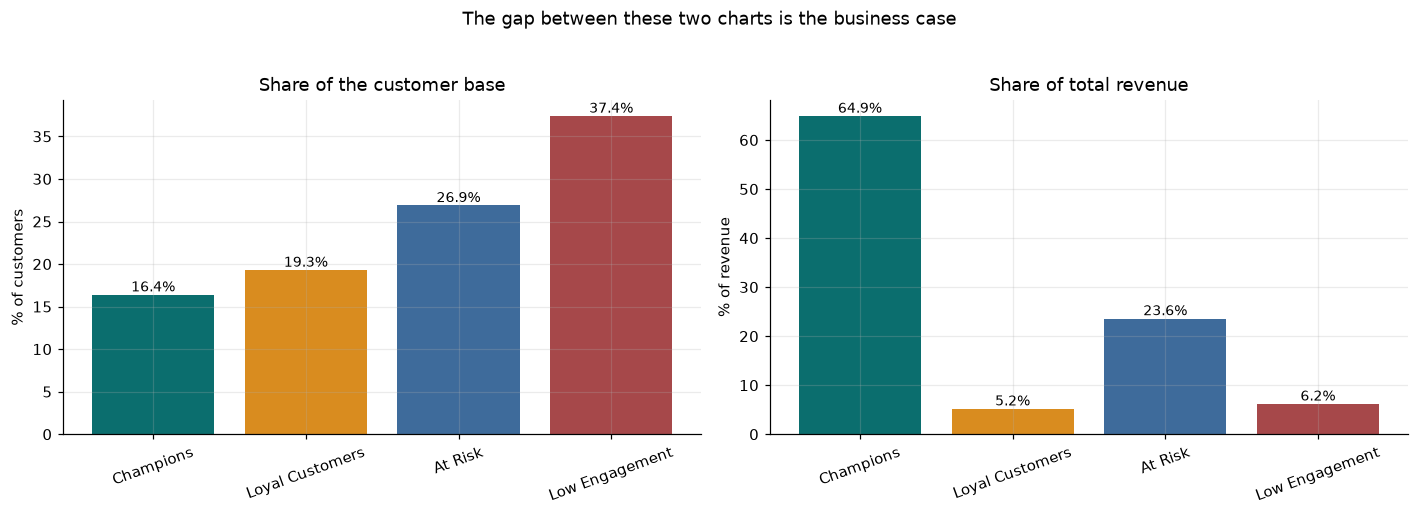

In [30]:
# Same table, ordered for plotting
plot_df = profile.set_index("Segment").loc[order]
colours = PALETTE[:K]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(plot_df.index, plot_df["Pct_of_Customers"], color=colours)
axes[0].set_ylabel("% of customers")
axes[0].set_title("Share of the customer base")

axes[1].bar(plot_df.index, plot_df["Pct_of_Revenue"], color=colours)
axes[1].set_ylabel("% of revenue")
axes[1].set_title("Share of total revenue")

# Label every bar with its value
for ax, column in zip(axes, ["Pct_of_Customers", "Pct_of_Revenue"]):
    for position, value in enumerate(plot_df[column]):
        ax.text(position, value, f"{value:.1f}%", ha="center", va="bottom", fontsize=9)
    ax.tick_params(axis="x", rotation=20)

fig.suptitle("The gap between these two charts is the business case", y=1.03, fontsize=12)
plt.tight_layout()
plt.show()

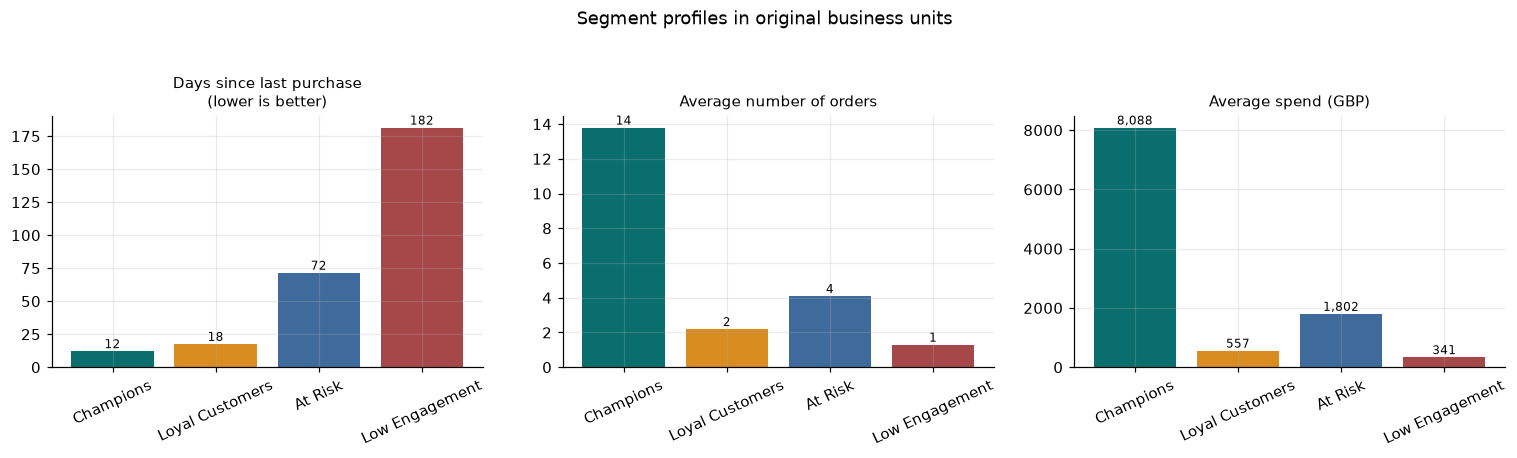

In [31]:
metrics = [
    ("Avg_Recency_days", "Days since last purchase\n(lower is better)"),
    ("Avg_Frequency_orders", "Average number of orders"),
    ("Avg_Monetary_GBP", "Average spend (GBP)"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (column, title) in zip(axes, metrics):
    ax.bar(plot_df.index, plot_df[column], color=colours)
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis="x", rotation=25)
    for position, value in enumerate(plot_df[column]):
        ax.text(position, value, f"{value:,.0f}", ha="center", va="bottom", fontsize=8)

fig.suptitle("Segment profiles in original business units", y=1.03, fontsize=12)
plt.tight_layout()
plt.show()

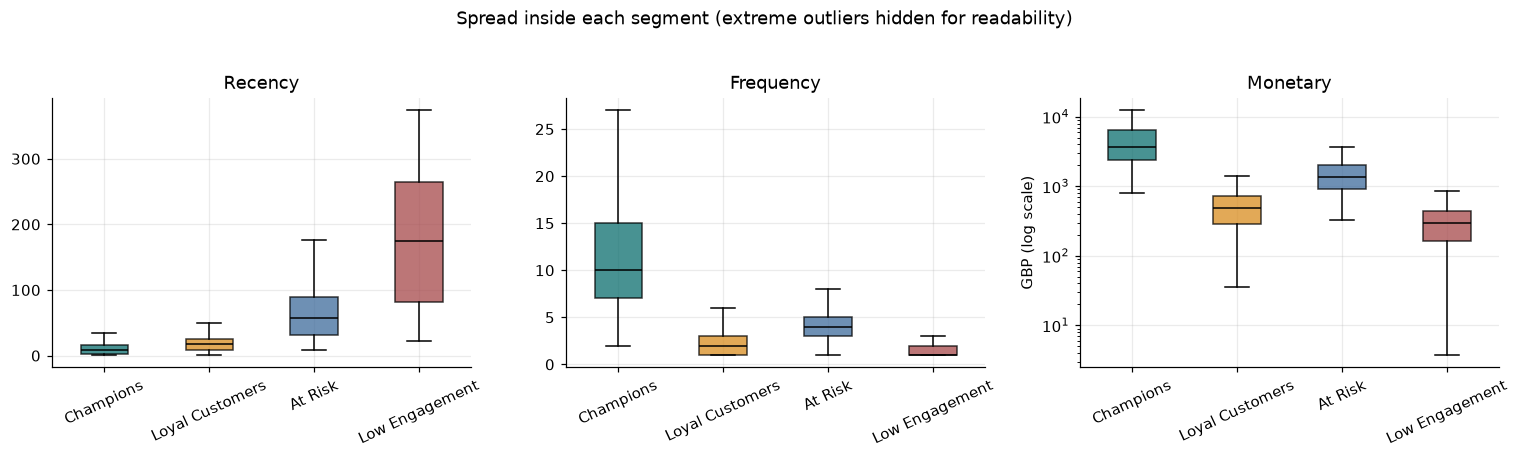

In [32]:
# Averages hide spread. These boxplots show how much the segments actually overlap.
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, column in zip(axes, FEATURES):
    values_per_segment = [rfm.loc[rfm["Segment"] == segment, column] for segment in order]
    box = ax.boxplot(values_per_segment, patch_artist=True, showfliers=False, tick_labels=order)

    for patch, colour in zip(box["boxes"], colours):
        patch.set_facecolor(colour)
        patch.set_alpha(0.75)
    for median in box["medians"]:
        median.set_color("black")

    ax.set_title(column)
    ax.tick_params(axis="x", rotation=25)

    if column == "Monetary":
        ax.set_yscale("log")
        ax.set_ylabel("GBP (log scale)")

fig.suptitle("Spread inside each segment (extreme outliers hidden for readability)", y=1.03, fontsize=12)
plt.tight_layout()
plt.show()

## 4.3 From segments to actions

Each segment now gets one treatment. This table is the actual deliverable: it is the thing
the Head of CRM signs off and executes.

In [33]:
ACTIONS = {
    "Champions": {
        "Action": "Loyalty rewards, early access, no discount",
        "Reason": "They already buy at full price. Discounting them destroys margin we would have earned anyway",
        "Budget": "Medium spend, high return",
    },
    "Loyal Customers": {
        "Action": "Cross-sell and volume incentives to move them up",
        "Reason": "Consistent buyers with room to grow. The cheapest route to more Champions",
        "Budget": "Medium spend",
    },
    "At Risk": {
        "Action": "Win-back campaign: personal contact plus a time-limited offer",
        "Reason": "They spent real money before. Recovering one is far cheaper than acquiring someone new",
        "Budget": "Highest priority for the retention budget",
    },
    "Low Engagement": {
        "Action": "Low-cost automated newsletter only, stop paid contact",
        "Reason": "What they contribute does not cover the cost per contact. This is where the savings come from",
        "Budget": "Minimal spend",
    },
}

action_table = pd.DataFrame(ACTIONS).T.loc[order]
action_table.index.name = "Segment"
action_table = action_table.join(summary[["Customers", "Pct_of_Revenue"]])

pd.set_option("display.max_colwidth", 90)
print("RECOMMENDED TREATMENT BY SEGMENT")
print(action_table.to_string())
pd.reset_option("display.max_colwidth")

RECOMMENDED TREATMENT BY SEGMENT
                                                                        Action                                                                                         Reason                                     Budget  Customers  Pct_of_Revenue
Segment                                                                                                                                                                                                                                            
Champions                           Loyalty rewards, early access, no discount   They already buy at full price. Discounting them destroys margin we would have earned anyway                  Medium spend, high return        713            64.9
Loyal Customers               Cross-sell and volume incentives to move them up                      Consistent buyers with room to grow. The cheapest route to more Champions                               Medium spend        837        

## 4.4 The recommendation

One recommendation, written the way we would say it to the Head of CRM.

In [34]:
champions_row = summary.loc["Champions"]
at_risk_row = summary.loc["At Risk"]
low_row = summary.loc["Low Engagement"]

line = "=" * 78
title = "RECOMMENDATION TO THE HEAD OF CRM".center(78)

# One f-string instead of twenty print calls, so the text is easy to read and edit here.
recommendation = f"""{line}
{title}
{line}

Stop sending one campaign to everyone. Split the customer base into the four segments
below and give each one a different treatment.

  1. CHAMPIONS are {champions_row['Pct_of_Customers']:.0f}% of customers and {champions_row['Pct_of_Revenue']:.0f}% of revenue.
     Protect them with recognition and service, not with discounts. They already buy at
     full price, so a discount here is margin given away for nothing.

  2. AT RISK is where the retention budget should go: {at_risk_row['Customers']:.0f} customers who averaged
     GBP {at_risk_row['Avg_Monetary_GBP']:,.0f} and have not bought in {at_risk_row['Avg_Recency_days']:.0f} days. They have already proved
     they will pay, and winning one back costs a fraction of acquiring someone new.

  3. LOW ENGAGEMENT is {low_row['Pct_of_Customers']:.0f}% of the base but only {low_row['Pct_of_Revenue']:.1f}% of revenue.
     Move them to a low-cost automated channel. That saving is what pays for the
     win-back campaign above.

HOW WE WILL KNOW IT WORKED (next quarter):
  - Repeat-purchase rate in At Risk against a held-out control group of At Risk customers
  - Revenue per contacted customer, by segment
  - Total marketing cost per customer, which should fall
  - Retention among Champions, which should hold
{line}"""

print(recommendation)

                      RECOMMENDATION TO THE HEAD OF CRM                       

Stop sending one campaign to everyone. Split the customer base into the four segments
below and give each one a different treatment.

  1. CHAMPIONS are 16% of customers and 65% of revenue.
     Protect them with recognition and service, not with discounts. They already buy at
     full price, so a discount here is margin given away for nothing.

  2. AT RISK is where the retention budget should go: 1166 customers who averaged
     GBP 1,802 and have not bought in 72 days. They have already proved
     they will pay, and winning one back costs a fraction of acquiring someone new.

  3. LOW ENGAGEMENT is 37% of the base but only 6.2% of revenue.
     Move them to a low-cost automated channel. That saving is what pays for the
     win-back campaign above.

HOW WE WILL KNOW IT WORKED (next quarter):
  - Repeat-purchase rate in At Risk against a held-out control group of At Risk customers
  - Revenue per contac

## 4.5 Dashboard

The next two cells build `dashboard.html`, a single self-contained file with the charts
embedded inside it. It opens in any browser with no server and no data connection. It is
rebuilt on every run, so it cannot drift out of sync with the analysis.

In [35]:
def figure_to_base64(fig):
    """Turn a matplotlib figure into a base64 PNG string.

    That string can be pasted straight into an <img> tag, which is how the dashboard
    stays a single file with no separate image files next to it.
    """
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", dpi=110, bbox_inches="tight")
    plt.close(fig)
    return base64.b64encode(buffer.getvalue()).decode("utf-8")


# Chart A: customers vs revenue, side by side
fig, ax = plt.subplots(figsize=(8, 4))
positions = np.arange(len(order))
bar_width = 0.38
ax.bar(positions - bar_width / 2, plot_df["Pct_of_Customers"], bar_width,
       label="% of customers", color=PALETTE[2])
ax.bar(positions + bar_width / 2, plot_df["Pct_of_Revenue"], bar_width,
       label="% of revenue", color=PALETTE[1])
ax.set_xticks(positions)
ax.set_xticklabels(order, rotation=15)
ax.set_ylabel("%")
ax.set_title("Customer share vs revenue share")
ax.legend(frameon=False)
chart_customers_vs_revenue = figure_to_base64(fig)

# Chart B: the same PCA map as §3.7, but labelled with the business names
fig, ax = plt.subplots(figsize=(6.5, 5))
for cluster in sorted(rfm["Cluster"].unique()):
    in_cluster = rfm["Cluster"].values == cluster
    ax.scatter(coords[in_cluster, 0], coords[in_cluster, 1], s=10, alpha=0.5,
               color=PALETTE[cluster], label=segment_name[cluster])
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Segment map")
ax.legend(frameon=False, fontsize=8)
chart_segment_map = figure_to_base64(fig)

# Chart C: average spend per segment
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(order, plot_df["Avg_Monetary_GBP"], color=colours)
ax.set_ylabel("GBP")
ax.set_title("Average spend per customer")
ax.tick_params(axis="x", rotation=15)
for position, value in enumerate(plot_df["Avg_Monetary_GBP"]):
    ax.text(position, value, f"{value:,.0f}", ha="center", va="bottom", fontsize=8)
chart_average_spend = figure_to_base64(fig)

print("Three charts encoded for the dashboard.")

Three charts encoded for the dashboard.


In [36]:
# The CSS lives in its own plain string, not an f-string, so the curly braces of the
# CSS rules do not need escaping.
CSS = """
body      { font-family: -apple-system, Segoe UI, Roboto, sans-serif; margin: 0;
            background: #f4f6f7; color: #1b2b2b; }
header    { background: #0B6E6E; color: #fff; padding: 26px 34px; }
header h1 { margin: 0 0 4px; font-size: 24px; }
header p  { margin: 0; opacity: .85; font-size: 13px; }
.wrap     { max-width: 1120px; margin: 0 auto; padding: 26px 20px 50px; }
.kpis     { display: grid; gap: 14px; margin-bottom: 26px;
            grid-template-columns: repeat(auto-fit, minmax(190px, 1fr)); }
.kpi      { background: #fff; border-radius: 8px; padding: 18px 20px;
            border-left: 4px solid #D98C1F; }
.kpi .value { font-size: 27px; font-weight: 700; color: #0B6E6E; }
.kpi .label { font-size: 11px; text-transform: uppercase; color: #67787a; }
.card     { background: #fff; border-radius: 8px; padding: 20px 24px; margin-bottom: 20px; }
.card h2  { margin: 0 0 14px; font-size: 16px; color: #0B6E6E;
            border-bottom: 2px solid #eef1f1; padding-bottom: 8px; }
.two      { display: grid; grid-template-columns: 1fr 1fr; gap: 20px; }
img       { max-width: 100%; height: auto; display: block; }
table     { width: 100%; border-collapse: collapse; font-size: 13px; }
th        { background: #0B6E6E; color: #fff; padding: 9px 10px; text-align: left; }
td        { padding: 9px 10px; border-bottom: 1px solid #eef1f1; }
footer    { text-align: center; font-size: 11px; color: #8a9a9c; padding: 16px; }
@media (max-width: 820px) { .two { grid-template-columns: 1fr; } }
"""

# The five numbers at the top of the page
kpis = [
    (f"{len(rfm):,}", "Customers segmented"),
    (f"&pound;{rfm['Monetary'].sum() / 1e6:.2f}M", "Total revenue analysed"),
    (f"{summary.loc['Champions', 'Pct_of_Revenue']:.0f}%", "Revenue from Champions"),
    (f"&pound;{rfm.loc[rfm['Segment'] == 'At Risk', 'Monetary'].sum() / 1000:,.0f}K", "Revenue at risk"),
    (f"{sil_test:.2f}", "Silhouette (held-out)"),
]

kpi_html = ""
for value, label in kpis:
    kpi_html += f"<div class='kpi'><div class='value'>{value}</div><div class='label'>{label}</div></div>"

# One table row per segment
table_html = ""
for segment in order:
    row = summary.loc[segment]
    table_html += (
        f"<tr><td><b>{segment}</b></td>"
        f"<td>{row['Customers']:,.0f}</td>"
        f"<td>{row['Pct_of_Customers']:.1f}%</td>"
        f"<td>{row['Avg_Recency_days']:.0f}</td>"
        f"<td>{row['Avg_Frequency_orders']:.1f}</td>"
        f"<td>&pound;{row['Avg_Monetary_GBP']:,.0f}</td>"
        f"<td>{row['Pct_of_Revenue']:.1f}%</td>"
        f"<td>{ACTIONS[segment]['Action']}</td></tr>"
    )

html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8">
<title>Customer Segmentation Dashboard | Team 4</title>
<style>{CSS}</style>
</head>
<body>

<header>
  <h1>Customer Segmentation Dashboard</h1>
  <p>Online Retail &middot; RFM K-means segmentation &middot; Team 4 &middot; IIB415A Business Intelligence</p>
</header>

<div class="wrap">

  <div class="kpis">{kpi_html}</div>

  <div class="card">
    <h2>Segments, profiles and recommended action</h2>
    <table>
      <tr>
        <th>Segment</th><th>Customers</th><th>% base</th><th>Recency (days)</th>
        <th>Orders</th><th>Avg spend</th><th>% revenue</th><th>Recommended action</th>
      </tr>
      {table_html}
    </table>
  </div>

  <div class="card">
    <h2>Customer share vs revenue share</h2>
    <img src="data:image/png;base64,{chart_customers_vs_revenue}" alt="Customer share versus revenue share">
  </div>

  <div class="two">
    <div class="card">
      <h2>Segment map</h2>
      <img src="data:image/png;base64,{chart_segment_map}" alt="Segment map">
    </div>
    <div class="card">
      <h2>Average spend per customer</h2>
      <img src="data:image/png;base64,{chart_average_spend}" alt="Average spend per customer">
    </div>
  </div>

</div>

<footer>Generated automatically from the project notebook &middot; Universidad del Desarrollo &middot; 2026</footer>

</body>
</html>"""

with open("dashboard.html", "w", encoding="utf-8") as f:
    f.write(html)

print("dashboard.html written.")
print("Open it in any browser. Everything is inside the file, images included.")

dashboard.html written.
Open it in any browser. Everything is inside the file, images included.


---
# 5 · Ethics, bias and limitations

## 5.1 Privacy

The dataset has no personal identifying information in it: no names, no addresses, no
emails, no payment details. Customers appear only as a pseudonymous numeric ID, which is the
right design for this analysis. We do not need to know who a customer is in order to know
how they buy.

Two things follow from that, and they matter in a real deployment:

- **Pseudonymous is not anonymous.** The retailer holds the mapping from `CustomerID` to a
  real business. Put that together with our output and a segment label becomes personal data
  about an identifiable customer under the UK GDPR. The segment table has to sit behind the
  same access controls as the CRM.
- **Purpose limitation.** This data was collected to process orders. Using it to decide who
  gets marketing is a compatible secondary use. Reusing it for credit scoring or selling it
  on would not be, and we would not support that.

## 5.2 Bias, in the data and in our own choices

**Geographic bias.** Almost all the transactions are from the United Kingdom, so what we
built is really a description of UK buying behaviour. Applied to other markets, where
delivery times, seasonality and typical order sizes are different, it would misclassify
customers in a systematic way.

**Survivorship bias from dropping missing `CustomerID`.** We removed a large block of rows
with no customer ID. If unregistered purchases are more common among a particular kind of
buyer, those buyers are simply absent from the segmentation and will never get a targeted
treatment. We had a good reason for the deletion, but the cost is real and it does not fall
evenly.

**Recency works against seasonal customers.** A business that legitimately orders once a
year in November will look very inactive in a January snapshot and land in At Risk or Low
Engagement. With twelve months of data we cannot tell a lost customer from a seasonal one.

**Our modelling choices are judgements, not facts.** We chose `log1p`, we chose to weight R,
F and M equally through standardisation, and we chose k = 4. Each of those changes who ends
up where. Equal weighting in particular is an assumption. The business may well think
Monetary matters more than Frequency, and if so the segments should be rebuilt with that
stated openly.

## 5.3 The self-fulfilling prophecy

This is the most serious ethical issue in the project, and it is easy to miss.

If we tell the client to stop contacting Low Engagement customers, those customers get fewer
offers, so they buy less, so they look even less engaged at the next refresh, so they get cut
further. The model then looks correct, but only because acting on it made it correct.

What we recommend to the client:

- Keep a control group inside Low Engagement that keeps receiving normal contact, so the
  effect of the policy can be measured instead of assumed.
- Never make a segment permanent. Recompute every quarter so customers can move.
- Keep a minimum level of contact for every segment. Segmentation should reallocate
  attention, not delete customers from the business.

## 5.4 Limitations

| # | Limitation | What it does to the decision |
|---|---|---|
| 1 | Only about 12 months of data, with one Christmas peak | Cannot separate seasonal customers from churning ones |
| 2 | Data is from 2010 to 2011 | The patterns are dated. The method transfers, the specific thresholds do not |
| 3 | Rows without `CustomerID` were dropped | Part of the real customer base is invisible to the segmentation |
| 4 | Cancellations excluded rather than netted off | Monetary value is slightly overstated for customers who returned goods |
| 5 | K-means assumes roughly spherical, similarly sized clusters | Customers near a boundary are assigned with low confidence |
| 6 | Only R, F and M were used | Product category, margin and acquisition channel would sharpen the segments |
| 7 | The segmentation describes, it does not explain | It says who is at risk, not why, and it does not prove an intervention will work |

## 5.5 What we would do next

1. Run the win-back campaign on At Risk as an A/B test against a holdout control, and
   measure the real lift instead of assuming it.
2. Add product category and margin, so "high spend" can be separated from "high profit".
3. Refresh the segmentation every quarter and track how customers move between segments.
   That migration is a stronger KPI than any static snapshot.

---
# 6 · Exported files

The cell below writes the files referenced by the README and the presentation.

In [37]:
# The customer-level output, which is the deliverable to the client
export = rfm.reset_index()[["CustomerID", "Recency", "Frequency", "Monetary",
                            "Country", "Cluster", "Segment"]]
export.to_csv("customer_segments.csv", index=False)

# The cleaned transactions, in a compact format for the ZIP.
# StockCode mixes numbers and text codes (22752 and "POST"), and Arrow cannot store both
# in one column, so we cast the text columns explicitly before writing.
df_out = df.copy()
for column in ["InvoiceNo", "StockCode", "Description", "CustomerID", "Country"]:
    df_out[column] = df_out[column].astype(str)

try:
    df_out.to_parquet("online_retail_clean.parquet", index=False)
    data_file = "online_retail_clean.parquet"
except Exception as error:
    df_out.to_csv("online_retail_clean.csv", index=False)
    data_file = "online_retail_clean.csv"
    print(f"(parquet not available: {error}. Wrote a CSV instead.)")

# The profile table for the slides
profile.to_csv("segment_profiles.csv")

print("FILES WRITTEN")
for filename in ["customer_segments.csv", data_file, "segment_profiles.csv", "dashboard.html"]:
    print(f"  - {filename}")

print("\nHEADLINE NUMBERS FOR THE SLIDES")
print(f"  Customers segmented        : {len(rfm):,}")
print(f"  Segments                   : {K}")
print(f"  Silhouette (held-out test) : {sil_test:.3f}")
print(f"  Silhouette (quintile base) : {sil_baseline:.3f}")
print(f"  Champions share of revenue : {summary.loc['Champions', 'Pct_of_Revenue']:.1f}%")
print(f"  Revenue sitting in At Risk : GBP {rfm.loc[rfm['Segment'] == 'At Risk', 'Monetary'].sum():,.0f}")

FILES WRITTEN
  - customer_segments.csv
  - online_retail_clean.parquet
  - segment_profiles.csv
  - dashboard.html

HEADLINE NUMBERS FOR THE SLIDES
  Customers segmented        : 4,338
  Segments                   : 4
  Silhouette (held-out test) : 0.337
  Silhouette (quintile base) : 0.170
  Champions share of revenue : 64.9%
  Revenue sitting in At Risk : GBP 2,100,873


---
# 7 · AI use disclosure

As required by §7 of the assignment brief, Team 4 discloses the following.

**Tool used:** Claude (Anthropic), through the web interface.

**What we used it for:**
- Discussing how to structure the notebook across the five required BI stages.
- Reviewing the wording of the English markdown, since the team works in Spanish.
- Discussing how to justify specific technical choices: the `log1p` transformation, the
  train/test discipline for an unsupervised model, and the choice of baselines.

**What we did not use it for:**
- The business framing, the choice of dataset, the choice of k and the marketing
  recommendations are the team's own decisions.

**Verification.** We ran and checked every cell in this notebook. Every number in the
markdown comes from the output of the cell above it. Each member can explain and defend the
code in the sections listed in the contribution table of the `README.md`.

---

*IIB415A · Business Intelligence · Universidad del Desarrollo · Team 4 · 2026*